In [2]:
import sys
!{sys.executable} -m pip install mcos_decoder

  Using cached mcos_decoder-0.1.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
Using cached mcos_decoder-0.1.0-py3-none-any.whl (8.9 kB)
Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl (37.3 MB)

   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   ---------------------------------------- 0/2 [scipy]
   --------


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from pathlib import Path
import cv2
import csv
from collections import defaultdict

from mcos_decoder import load_groundtruth

In [ ]:
DATA_ROOT = Path(r"F:\Datasets\Drone-detection-2021-dataset\Data")

VIDEO_DIR = DATA_ROOT / "Video_V"

OUTPUT = Path(r"F:\Datasets\DroneDetection2021_YOLO_Unified")

OUT_IMAGES = OUTPUT / "images" / "all"
OUT_LABELS = OUTPUT / "labels" / "all"

OUT_IMAGES.mkdir(parents=True, exist_ok=True)
OUT_LABELS.mkdir(parents=True, exist_ok=True)


FRAME_STEP = 5

# If bbox is None:
# True  = create empty label file
# False = skip that frame completely
# Based on the test script that was in the github repo
KEEP_ABSENT_FRAMES_AS_EMPTY = True

CLASS_MAP = {
    "DRONE": 0,
    "BIRD": 1,
    "AIRPLANE": 2,
    "HELICOPTER": 3,
}

print("Video dir exists:", VIDEO_DIR.exists())
print("Output:", OUTPUT)

Video dir exists: True
Output: F:\Datasets\DroneDetection2021_YOLO_Unified


In [5]:
def infer_class_from_filename(filename: str):
    """
    Example:
    V_DRONE_001.mp4 -> DRONE
    V_AIRPLANE_008.mp4 -> AIRPLANE
    """
    name = filename.upper()

    if "DRONE" in name:
        return "DRONE"
    if "BIRD" in name:
        return "BIRD"
    if "AIRPLANE" in name:
        return "AIRPLANE"
    if "HELICOPTER" in name:
        return "HELICOPTER"

    return None


def absolute_xywh_to_yolo(x, y, w, h, img_w, img_h):
    """
    Convert absolute xywh to YOLO normalized center xywh.
    """
    x_center = (x + w / 2) / img_w
    y_center = (y + h / 2) / img_h
    yolo_w = w / img_w
    yolo_h = h / img_h

    return x_center, y_center, yolo_w, yolo_h


def valid_yolo_box(xc, yc, w, h):
    return (
        0 <= xc <= 1 and
        0 <= yc <= 1 and
        0 < w <= 1 and
        0 < h <= 1
    )

In [6]:
video_files = sorted(list(VIDEO_DIR.glob("*.mp4")))

pairs = []

for video_path in video_files:
    mat_path = video_path.with_name(video_path.stem + "_LABELS.mat")

    class_name = infer_class_from_filename(video_path.name)

    if mat_path.exists() and class_name is not None:
        pairs.append({
            "video_path": video_path,
            "mat_path": mat_path,
            "class_name": class_name,
            "class_id": CLASS_MAP[class_name],
        })
    else:
        print("[SKIP]", video_path.name, "| mat exists:", mat_path.exists(), "| class:", class_name)

print("Valid video-label pairs:", len(pairs))

for p in pairs[:10]:
    print(p["video_path"].name, "->", p["mat_path"].name, "|", p["class_name"])

Valid video-label pairs: 285
V_AIRPLANE_001.mp4 -> V_AIRPLANE_001_LABELS.mat | AIRPLANE
V_AIRPLANE_002.mp4 -> V_AIRPLANE_002_LABELS.mat | AIRPLANE
V_AIRPLANE_003.mp4 -> V_AIRPLANE_003_LABELS.mat | AIRPLANE
V_AIRPLANE_004.mp4 -> V_AIRPLANE_004_LABELS.mat | AIRPLANE
V_AIRPLANE_005.mp4 -> V_AIRPLANE_005_LABELS.mat | AIRPLANE
V_AIRPLANE_006.mp4 -> V_AIRPLANE_006_LABELS.mat | AIRPLANE
V_AIRPLANE_007.mp4 -> V_AIRPLANE_007_LABELS.mat | AIRPLANE
V_AIRPLANE_008.mp4 -> V_AIRPLANE_008_LABELS.mat | AIRPLANE
V_AIRPLANE_009.mp4 -> V_AIRPLANE_009_LABELS.mat | AIRPLANE
V_AIRPLANE_010.mp4 -> V_AIRPLANE_010_LABELS.mat | AIRPLANE


In [7]:
# conversion test
sample = pairs[0]

print(sample)

bboxes = load_groundtruth(str(sample["mat_path"]))

print("Number of bbox entries:", len(bboxes))
print("First 10 entries:")
for i, bbox in enumerate(bboxes[:10], start=1):
    print(i, bbox)

{'video_path': WindowsPath('F:/Datasets/Drone-detection-2021-dataset/Data/Video_V/V_AIRPLANE_001.mp4'), 'mat_path': WindowsPath('F:/Datasets/Drone-detection-2021-dataset/Data/Video_V/V_AIRPLANE_001_LABELS.mat'), 'class_name': 'AIRPLANE', 'class_id': 2}
Number of bbox entries: 327
First 10 entries:
1 (313.0, 205.0, 36.0, 24.0)
2 (313.44818115234375, 204.4243621826172, 36.065673828125, 24.117782592773438)
3 (311.4893798828125, 204.3994598388672, 36.054718017578125, 24.105926513671875)
4 (309.9466552734375, 203.3891143798828, 36.08734130859375, 24.109298706054688)
5 (308.95916748046875, 203.63333129882812, 36.10455322265625, 24.13519287109375)
6 (307.9422302246094, 203.58889770507812, 36.1192626953125, 24.145156860351562)
7 (305.9923400878906, 203.306884765625, 36.386322021484375, 24.307205200195312)
8 (306.8854064941406, 203.41610717773438, 36.087493896484375, 24.086624145507812)
9 (304.9924011230469, 203.31063842773438, 36.4029541015625, 24.32647705078125)
10 (303.27850341796875, 202.53

In [8]:
manifest_rows = []
invalid_rows = []

total_frames_seen = 0
total_frames_saved = 0
total_boxes_saved = 0
absent_frames = 0
frame_mismatch_videos = []

for item in pairs:
    video_path = item["video_path"]
    mat_path = item["mat_path"]
    class_name = item["class_name"]
    class_id = item["class_id"]

    print("=" * 80)
    print("Processing:", video_path.name, "| class:", class_name)

    bboxes = load_groundtruth(str(mat_path))

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        print("[ERROR] Could not open video:", video_path)
        continue

    video_frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    video_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    video_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print("Video frames:", video_frame_count)
    print("BBox entries:", len(bboxes))
    print("Resolution:", video_width, "x", video_height)

    if abs(video_frame_count - len(bboxes)) > 2:
        frame_mismatch_videos.append({
            "video": video_path.name,
            "video_frame_count": video_frame_count,
            "bbox_count": len(bboxes),
        })
        print("[WARNING] Frame count mismatch!")

    frame_idx = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        frame_idx += 1
        total_frames_seen += 1

        # Apply frame step
        if (frame_idx - 1) % FRAME_STEP != 0:
            continue

        # Make sure bbox index exists
        if frame_idx - 1 >= len(bboxes):
            continue

        bbox = bboxes[frame_idx - 1]

        if bbox is None:
            absent_frames += 1

            if not KEEP_ABSENT_FRAMES_AS_EMPTY:
                continue

            label_lines = []
        else:
            x, y, w, h = bbox

            xc, yc, yw, yh = absolute_xywh_to_yolo(
                x, y, w, h,
                video_width,
                video_height
            )

            if not valid_yolo_box(xc, yc, yw, yh):
                invalid_rows.append({
                    "video": video_path.name,
                    "frame_idx": frame_idx,
                    "bbox": str(bbox),
                    "reason": "invalid YOLO conversion",
                    "xc": xc,
                    "yc": yc,
                    "w": yw,
                    "h": yh,
                })
                continue

            label_lines = [
                f"{class_id} {xc:.6f} {yc:.6f} {yw:.6f} {yh:.6f}"
            ]

        # Create unique frame name
        frame_stem = f"{video_path.stem}__frame_{frame_idx:06d}"
        image_name = frame_stem + ".jpg"
        label_name = frame_stem + ".txt"

        out_img = OUT_IMAGES / image_name
        out_lbl = OUT_LABELS / label_name

        cv2.imwrite(str(out_img), frame)

        with open(out_lbl, "w", encoding="utf-8") as f:
            if label_lines:
                f.write("\n".join(label_lines) + "\n")
            else:
                # Empty label file for absent frame
                f.write("")

        total_frames_saved += 1
        total_boxes_saved += len(label_lines)

        manifest_rows.append({
            "image": image_name,
            "label": label_name,
            "video": video_path.name,
            "mat": mat_path.name,
            "frame_idx": frame_idx,
            "class_name": class_name,
            "class_id": class_id,
            "has_bbox": bbox is not None,
            "num_boxes": len(label_lines),
            "video_width": video_width,
            "video_height": video_height,
        })

    cap.release()

print("=" * 80)
print("CONVERSION DONE")
print("=" * 80)
print("Total frames seen:", total_frames_seen)
print("Total frames saved:", total_frames_saved)
print("Total boxes saved:", total_boxes_saved)
print("Absent frames:", absent_frames)
print("Invalid rows:", len(invalid_rows))
print("Frame mismatch videos:", len(frame_mismatch_videos))

Processing: V_AIRPLANE_001.mp4 | class: AIRPLANE
Video frames: 327
BBox entries: 327
Resolution: 640 x 512
Processing: V_AIRPLANE_002.mp4 | class: AIRPLANE
Video frames: 301
BBox entries: 300
Resolution: 640 x 512
Processing: V_AIRPLANE_003.mp4 | class: AIRPLANE
Video frames: 327
BBox entries: 327
Resolution: 640 x 512
Processing: V_AIRPLANE_004.mp4 | class: AIRPLANE
Video frames: 319
BBox entries: 319
Resolution: 640 x 512
Processing: V_AIRPLANE_005.mp4 | class: AIRPLANE
Video frames: 328
BBox entries: 328
Resolution: 640 x 512
Processing: V_AIRPLANE_006.mp4 | class: AIRPLANE
Video frames: 312
BBox entries: 312
Resolution: 640 x 512
Processing: V_AIRPLANE_007.mp4 | class: AIRPLANE
Video frames: 300
BBox entries: 300
Resolution: 640 x 512
Processing: V_AIRPLANE_008.mp4 | class: AIRPLANE
Video frames: 320
BBox entries: 320
Resolution: 640 x 512
Processing: V_AIRPLANE_009.mp4 | class: AIRPLANE
Video frames: 325
BBox entries: 325
Resolution: 640 x 512
Processing: V_AIRPLANE_010.mp4 | clas

In [9]:
manifest_path = OUTPUT / "manifest.csv"
invalid_path = OUTPUT / "invalid_labels.csv"
mismatch_path = OUTPUT / "frame_mismatches.csv"

with open(manifest_path, "w", encoding="utf-8", newline="") as f:
    fieldnames = [
        "image",
        "label",
        "video",
        "mat",
        "frame_idx",
        "class_name",
        "class_id",
        "has_bbox",
        "num_boxes",
        "video_width",
        "video_height",
    ]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(manifest_rows)

with open(invalid_path, "w", encoding="utf-8", newline="") as f:
    fieldnames = [
        "video",
        "frame_idx",
        "bbox",
        "reason",
        "xc",
        "yc",
        "w",
        "h",
    ]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(invalid_rows)

with open(mismatch_path, "w", encoding="utf-8", newline="") as f:
    fieldnames = [
        "video",
        "video_frame_count",
        "bbox_count",
    ]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(frame_mismatch_videos)

print("Saved:")
print(manifest_path)
print(invalid_path)
print(mismatch_path)

Saved:
F:\Datasets\DroneDetection2021_YOLO_Unified\manifest.csv
F:\Datasets\DroneDetection2021_YOLO_Unified\invalid_labels.csv
F:\Datasets\DroneDetection2021_YOLO_Unified\frame_mismatches.csv


In [10]:
data_yaml_path = OUTPUT / "data.yaml"

with open(data_yaml_path, "w", encoding="utf-8") as f:
    f.write(f"path: {str(OUTPUT).replace(chr(92), '/')}\n")
    f.write("train: images/all\n")
    f.write("val: images/all\n")
    f.write("test: images/all\n")
    f.write("\n")
    f.write("names:\n")
    f.write("  0: drone\n")
    f.write("  1: bird\n")
    f.write("  2: airplane\n")
    f.write("  3: helicopter\n")

print(open(data_yaml_path, "r", encoding="utf-8").read())

path: F:/Datasets/DroneDetection2021_YOLO_Unified
train: images/all
val: images/all
test: images/all

names:
  0: drone
  1: bird
  2: airplane
  3: helicopter



In [11]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

images = [p for p in OUT_IMAGES.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
labels = [p for p in OUT_LABELS.iterdir() if p.is_file() and p.suffix.lower() == ".txt"]

image_stems = {p.stem for p in images}
label_stems = {p.stem for p in labels}

print("Images:", len(images))
print("Labels:", len(labels))
print("Images without labels:", len(image_stems - label_stems))
print("Labels without images:", len(label_stems - image_stems))

Images: 17707
Labels: 17707
Images without labels: 0
Labels without images: 0


In [12]:
import random

label_files = list(OUT_LABELS.glob("*.txt"))

sample_size = min(500, len(label_files))
sample_labels = random.sample(label_files, sample_size)

invalid_lines = []
class_ids = set()
total_boxes = 0
empty_label_files = 0

for label_path in sample_labels:
    with open(label_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    if len(lines) == 0:
        empty_label_files += 1
        continue

    for line_num, line in enumerate(lines, start=1):
        parts = line.split()

        if len(parts) != 5:
            invalid_lines.append((label_path.name, line_num, line, "not 5 values"))
            continue

        cls, xc, yc, w, h = parts

        try:
            cls = int(cls)
            xc = float(xc)
            yc = float(yc)
            w = float(w)
            h = float(h)
        except ValueError:
            invalid_lines.append((label_path.name, line_num, line, "non-numeric"))
            continue

        class_ids.add(cls)
        total_boxes += 1

        if cls not in {0, 1, 2, 3}:
            invalid_lines.append((label_path.name, line_num, line, "invalid class id"))

        if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 < w <= 1 and 0 < h <= 1):
            invalid_lines.append((label_path.name, line_num, line, "invalid YOLO coordinates"))

print("Checked label files:", sample_size)
print("Total boxes checked:", total_boxes)
print("Empty label files:", empty_label_files)
print("Class IDs found:", class_ids)
print("Invalid label lines:", len(invalid_lines))

if invalid_lines:
    print(invalid_lines[:20])

Checked label files: 500
Total boxes checked: 480
Empty label files: 20
Class IDs found: {0, 1, 2, 3}
Invalid label lines: 0


In [16]:
import sys
!{sys.executable} -m pip install Pillow matplotlib

  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 2.0 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.5 MB 2.3 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.5 MB 2.4 MB/s eta 0:00:04
   ----------- ---------------------------- 2.6/9.5 MB 2.5 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.5 MB 2.6 MB/s eta 0:00:03
   --------------- ------------------------ 3.7/9.5 MB 2.7 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.5 MB 2.7 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.5 MB 2.7 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Matplotlib is building the font cache; this may take a moment.


Valid image-label pairs: 17707


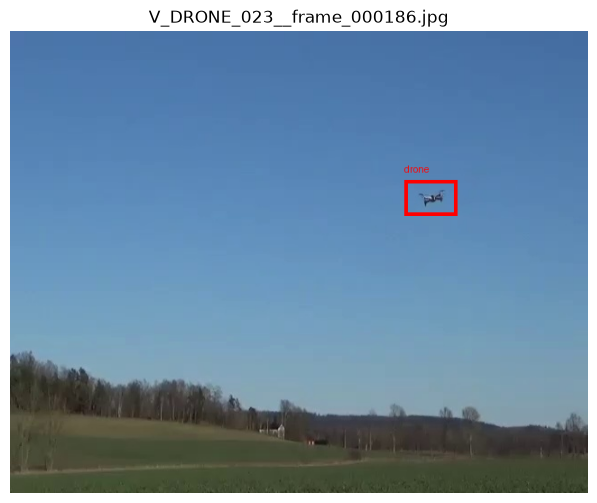

Saved: F:\Datasets\DroneDetection2021_YOLO_Unified\bbox_visual_check\sample_1_V_DRONE_023__frame_000186.jpg


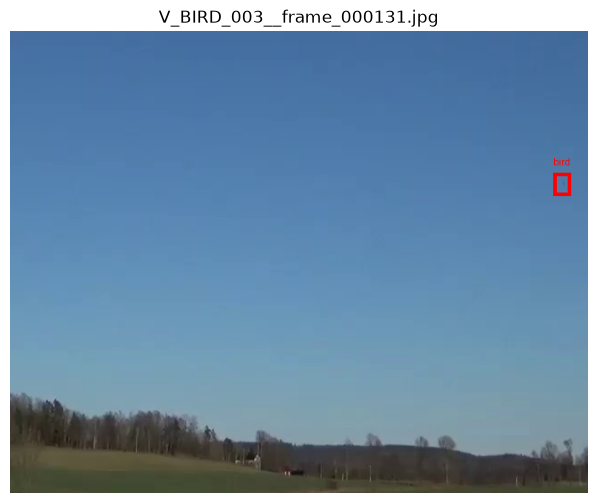

Saved: F:\Datasets\DroneDetection2021_YOLO_Unified\bbox_visual_check\sample_2_V_BIRD_003__frame_000131.jpg


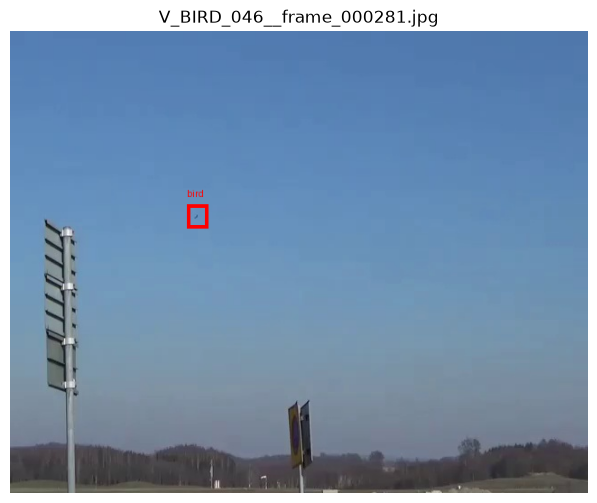

Saved: F:\Datasets\DroneDetection2021_YOLO_Unified\bbox_visual_check\sample_3_V_BIRD_046__frame_000281.jpg


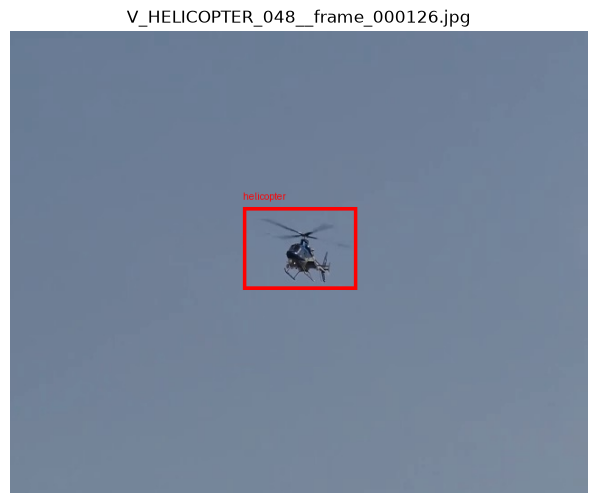

Saved: F:\Datasets\DroneDetection2021_YOLO_Unified\bbox_visual_check\sample_4_V_HELICOPTER_048__frame_000126.jpg


In [17]:
from pathlib import Path
import random
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt


DATASET = Path(r"F:\Datasets\DroneDetection2021_YOLO_Unified")

IMAGES_DIR = DATASET / "images" / "all"
LABELS_DIR = DATASET / "labels" / "all"

OUTPUT_DIR = DATASET / "bbox_visual_check"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

CLASS_NAMES = {
    0: "drone",
    1: "bird",
    2: "airplane",
    3: "helicopter",
}

# Collect images that have matching labels
image_paths = [
    p for p in IMAGES_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
]

valid_pairs = []

for image_path in image_paths:
    label_path = LABELS_DIR / f"{image_path.stem}.txt"
    if label_path.exists():
        valid_pairs.append((image_path, label_path))

print("Valid image-label pairs:", len(valid_pairs))

sample_pairs = random.sample(valid_pairs, min(4, len(valid_pairs)))


def draw_yolo_boxes(image_path: Path, label_path: Path):
    image = Image.open(image_path).convert("RGB")
    img_w, img_h = image.size

    draw = ImageDraw.Draw(image)

    with open(label_path, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    if len(lines) == 0:
        draw.text((20, 20), "EMPTY LABEL FILE", fill="red")
        return image

    for line in lines:
        parts = line.split()

        if len(parts) != 5:
            print(f"Invalid label line in {label_path.name}: {line}")
            continue

        class_id, xc, yc, bw, bh = parts

        class_id = int(class_id)
        xc = float(xc)
        yc = float(yc)
        bw = float(bw)
        bh = float(bh)

        # YOLO normalized center xywh -> pixel x1 y1 x2 y2
        x1 = int((xc - bw / 2) * img_w)
        y1 = int((yc - bh / 2) * img_h)
        x2 = int((xc + bw / 2) * img_w)
        y2 = int((yc + bh / 2) * img_h)

        class_name = CLASS_NAMES.get(class_id, f"class_{class_id}")

        draw.rectangle([x1, y1, x2, y2], outline="red", width=4)

        text = class_name
        text_x = x1
        text_y = max(y1 - 18, 0)

        draw.text((text_x, text_y), text, fill="red")

    return image


for idx, (image_path, label_path) in enumerate(sample_pairs, start=1):
    img = draw_yolo_boxes(image_path, label_path)

    save_path = OUTPUT_DIR / f"sample_{idx}_{image_path.name}"
    img.save(save_path)

    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title(f"{image_path.name}")
    plt.axis("off")
    plt.show()

    print("Saved:", save_path)

In [18]:
#Drone-only extraction
from pathlib import Path
import shutil
import csv

DATASET = Path(r"F:\Datasets\DroneDetection2021_YOLO_Unified")

SRC_IMAGES = DATASET / "images" / "all"
SRC_LABELS = DATASET / "labels" / "all"

DRONES_OUT = DATASET / "Drones"

OUT_IMAGES = DRONES_OUT / "images" / "all"
OUT_LABELS = DRONES_OUT / "labels" / "all"

OUT_IMAGES.mkdir(parents=True, exist_ok=True)
OUT_LABELS.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

DRONE_CLASS_ID = "0"

manifest_rows = []

copied_images = 0
copied_labels = 0
skipped_non_drone = 0
empty_labels = 0
invalid_lines = 0

label_files = sorted(SRC_LABELS.glob("*.txt"))

print("Source label files:", len(label_files))

for label_path in label_files:
    with open(label_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    if len(lines) == 0:
        empty_labels += 1
        continue

    drone_lines = []

    for line in lines:
        parts = line.split()

        if len(parts) != 5:
            invalid_lines += 1
            continue

        cls, xc, yc, w, h = parts

        if cls == DRONE_CLASS_ID:
            # Keep class as 0 for drone-only YOLO dataset
            drone_lines.append(f"0 {xc} {yc} {w} {h}")

    if len(drone_lines) == 0:
        skipped_non_drone += 1
        continue

    # Find matching image by stem
    image_path = None

    for ext in IMAGE_EXTS:
        candidate = SRC_IMAGES / f"{label_path.stem}{ext}"
        if candidate.exists():
            image_path = candidate
            break

    if image_path is None:
        print("[WARNING] No image found for label:", label_path.name)
        continue

    out_image_path = OUT_IMAGES / image_path.name
    out_label_path = OUT_LABELS / label_path.name

    shutil.copy2(image_path, out_image_path)

    with open(out_label_path, "w", encoding="utf-8") as f:
        f.write("\n".join(drone_lines) + "\n")

    copied_images += 1
    copied_labels += 1

    manifest_rows.append({
        "image": image_path.name,
        "label": label_path.name,
        "source_image": str(image_path),
        "source_label": str(label_path),
        "num_drone_boxes": len(drone_lines),
    })

manifest_path = DRONES_OUT / "manifest_drones.csv"

with open(manifest_path, "w", encoding="utf-8", newline="") as f:
    fieldnames = [
        "image",
        "label",
        "source_image",
        "source_label",
        "num_drone_boxes",
    ]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(manifest_rows)

data_yaml_path = DRONES_OUT / "data.yaml"

with open(data_yaml_path, "w", encoding="utf-8") as f:
    f.write(f"path: {str(DRONES_OUT).replace(chr(92), '/')}\n")
    f.write("train: images/all\n")
    f.write("val: images/all\n")
    f.write("test: images/all\n")
    f.write("\n")
    f.write("names:\n")
    f.write("  0: drone\n")

print("=" * 80)
print("DRONE-ONLY EXTRACTION SUMMARY")
print("=" * 80)
print("Copied images:", copied_images)
print("Copied labels:", copied_labels)
print("Skipped non-drone labels:", skipped_non_drone)
print("Empty labels skipped:", empty_labels)
print("Invalid lines skipped:", invalid_lines)
print("Manifest:", manifest_path)
print("data.yaml:", data_yaml_path)

Source label files: 17707
DRONE-ONLY EXTRACTION SUMMARY
Copied images: 6874
Copied labels: 6874
Skipped non-drone labels: 10044
Empty labels skipped: 789
Invalid lines skipped: 0
Manifest: F:\Datasets\DroneDetection2021_YOLO_Unified\Drones\manifest_drones.csv
data.yaml: F:\Datasets\DroneDetection2021_YOLO_Unified\Drones\data.yaml


In [19]:
from pathlib import Path

DRONES_OUT = Path(r"F:\Datasets\DroneDetection2021_YOLO_Unified\Drones")

IMAGES_DIR = DRONES_OUT / "images" / "all"
LABELS_DIR = DRONES_OUT / "labels" / "all"

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

images = [p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTS]
labels = [p for p in LABELS_DIR.iterdir() if p.suffix.lower() == ".txt"]

image_stems = {p.stem for p in images}
label_stems = {p.stem for p in labels}

print("Images:", len(images))
print("Labels:", len(labels))
print("Images without labels:", len(image_stems - label_stems))
print("Labels without images:", len(label_stems - image_stems))

Images: 6874
Labels: 6874
Images without labels: 0
Labels without images: 0


In [20]:
# check labels are all class 0
invalid_lines = []
class_ids = set()
total_boxes = 0

for label_path in LABELS_DIR.glob("*.txt"):
    with open(label_path, "r", encoding="utf-8", errors="ignore") as f:
        for line_num, line in enumerate(f, start=1):
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            if len(parts) != 5:
                invalid_lines.append((label_path.name, line_num, line, "not 5 values"))
                continue

            cls, xc, yc, w, h = parts

            class_ids.add(cls)
            total_boxes += 1

            if cls != "0":
                invalid_lines.append((label_path.name, line_num, line, "not drone class"))

print("Total boxes:", total_boxes)
print("Class IDs found:", class_ids)
print("Invalid lines:", len(invalid_lines))

Total boxes: 6874
Class IDs found: {'0'}
Invalid lines: 0
